# Step 1 — Comparing Optimizers and Tuning the GPU with Environment Variables

**CUDA-Q QAOA GPU-Optimization Learning Path · notebook 1**

Notebook 0 solved the 16-qubit, 4-region Taiwan map-coloring problem with COBYLA on both a CPU
and a GPU simulator. Here we stay on the same problem and the same p=1 QAOA circuit, but push two
knobs that notebook 0 left untouched:

1. **Environment variables** that CUDA-Q reads once, at import time, to tune how the GPU
   simulator fuses gates and how many host threads it uses.
2. **The classical optimizer itself** — we swap COBYLA for Nelder-Mead and see how much further
   the same 50-evaluation budget can push the energy down.

Everything about the problem (regions, edges, penalty weights, seed) is reused exactly from
notebook 0.

In [1]:
# cell 1 — CUDAQ_* environment variables (must be set before `import cudaq`), then rebuild the problem.
import os
os.environ["CUDAQ_FUSION_MAX_QUBITS"] = "3"
os.environ["CUDAQ_FUSION_NUM_HOST_THREADS"] = "4"
# Changing these two variables again later requires restarting the kernel: CUDA-Q reads them once,
# the moment `cudaq` is imported.

import sys, time
import matplotlib.pyplot as plt
import helpers as hp
import cudaq

cudaq.set_random_seed(1234)
cudaq.set_target("nvidia", option="fp32")
print(f"CUDA-Q {cudaq.__version__.split()[2]}   Python {sys.version.split()[0]}")

taiwan = hp.load_map()
NODES = hp.REGION_ORDER              # ["North", "Central", "South", "East"]
EDGES = taiwan["region_edges"]
K = 4
A, B = 4.0, 1.0
N = len(NODES) * K                   # 16 qubits

coeffs, qubo_offset = hp.build_qubo(NODES, EDGES, K, A, B)
H, terms, offset = hp.qubo_to_spin(coeffs, qubo_offset)
print(f"{len(NODES)} regions x {K} colors = {N} qubits")
print(f"spin Hamiltonian: {len(terms['z'])} Z terms + {len(terms['zz'])} ZZ terms, "
      f"constant offset {offset}")

CUDA-Q amd64-cu13-0.15.0   Python 3.12.3
4 regions x 4 colors = 16 qubits
spin Hamiltonian: 16 Z terms + 44 ZZ terms, constant offset 37.0


## The p=1 QAOA circuit

Identical to notebook 0: a Hadamard start, one cost layer (built only from `rz` and pairs of
`cx`), one mixer layer (`rx`) — only 1- and 2-qubit gates. `energy(params)` wraps
`cudaq.observe` and adds the constant offset back in, so a perfect coloring reads exactly 0.

In [2]:
# cell 2 — the p = 1 QAOA circuit and the energy(params) function, reused from notebook 0.
@cudaq.kernel
def qaoa_kernel(n: int, zq: list[int], zc: list[float], zz1: list[int],
                zz2: list[int], zzc: list[float], gammas: list[float], betas: list[float]):
    q = cudaq.qvector(n)
    h(q)                                              # start in superposition
    for layer in range(len(gammas)):
        for i in range(len(zq)):                      # cost layer: Z terms
            rz(2.0 * gammas[layer] * zc[i], q[zq[i]])
        for i in range(len(zz1)):                     # cost layer: ZZ terms
            x.ctrl(q[zz1[i]], q[zz2[i]])
            rz(2.0 * gammas[layer] * zzc[i], q[zz2[i]])
            x.ctrl(q[zz1[i]], q[zz2[i]])
        for i in range(n):                            # mixer layer
            rx(2.0 * betas[layer], q[i])

zq, zc, zz1, zz2, zzc = hp.terms_to_lists(terms)

def energy(params):
    gamma = params[0]
    beta = params[1]
    return cudaq.observe(qaoa_kernel, H, N, zq, zc, zz1, zz2, zzc,
                         [gamma], [beta]).expectation() + offset

print(f"energy at gamma = 0, beta = 0:  {energy([0.0, 0.0]):.3f}   (expected: the offset, 37)")

energy at gamma = 0, beta = 0:  37.000   (expected: the offset, 37)


## Optimize with Nelder-Mead

Notebook 0 used COBYLA with a 50-evaluation budget and landed at some best energy on the GPU.
Here we run the *same* budget (50 evaluations, same starting angles gamma=0.1, beta=0.1) but with
`cudaq.optimizers.NelderMead` instead. Each call to `energy()` is timed in GPU milliseconds and
printed next to the energy it found, so we can watch the search happen evaluation by evaluation.

In [3]:
# cell 3 — optimize with Nelder-Mead, timing every energy() call.
num_iterations = 50
START = [0.1, 0.1]

step = [0]
def timed_energy(params):
    t0 = time.perf_counter()
    value = energy(params)
    step[0] += 1
    print(f"  iteration {step[0]:2d}: {(time.perf_counter() - t0) * 1e3:8.2f} ms   energy {value:.4f}")
    return value

optimizer = cudaq.optimizers.NelderMead()
optimizer.max_iterations = num_iterations
optimizer.initial_parameters = START

t0 = time.perf_counter()
best_energy, best_angles = optimizer.optimize(dimensions=2, function=timed_energy)
opt_seconds = time.perf_counter() - t0

print(f"\nNelder-Mead (GPU): best energy {best_energy:.6f} at gamma = {best_angles[0]:.4f}, "
      f"beta = {best_angles[1]:.4f}   ({opt_seconds:.3f} s total, {num_iterations} evaluations)")

# Provenance: notebook 0's COBYLA run on the same 50-evaluation budget, same GPU target, same seed.
cobyla_best_energy_notebook0 = 17.305686  # from 00_notebook.ipynb's GPU (nvidia) COBYLA run
print(f"for comparison, notebook 0's COBYLA best energy on the same budget: "
      f"{cobyla_best_energy_notebook0:.6f}")

  iteration  1:     3.09 ms   energy 51.0405
  iteration  2:     2.56 ms   energy 35.8708
  iteration  3:     2.41 ms   energy 33.3275
  iteration  4:     2.44 ms   energy 37.0395
  iteration  5:     2.07 ms   energy 36.6493
  iteration  6:     1.75 ms   energy 21.4952
  iteration  7:     4.30 ms   energy 51.0405
  iteration  8:     1.73 ms   energy 90.5233
  iteration  9:     2.43 ms   energy 61.8713
  iteration 10:     2.27 ms   energy 36.3457
  iteration 11:     2.10 ms   energy 43.7724
  iteration 12:     2.07 ms   energy 62.4833
  iteration 13:     2.09 ms   energy 54.2868
  iteration 14:     2.13 ms   energy 46.0352
  iteration 15:     2.11 ms   energy 47.2230
  iteration 16:     2.40 ms   energy 31.3153
  iteration 17:     2.09 ms   energy 45.1728
  iteration 18:     2.82 ms   energy 18.0647
  iteration 19:     2.11 ms   energy 11.4229
  iteration 20:     1.73 ms   energy 16.6752
  iteration 21:     1.81 ms   energy 50.5606
  iteration 22:     1.71 ms   energy 12.0025
  iteratio

## Sample the optimized circuit

With the Nelder-Mead angles fixed, we sample the circuit 20,000 times and decode each bitstring
back into a coloring, exactly as in notebook 0. The one check of this notebook: the best sampled
bitstring must be a valid coloring.

In [4]:
# cell 4 — sample 20,000 shots, summarize, and check the best result is a valid coloring.
shots = cudaq.sample(qaoa_kernel, N, zq, zc, zz1, zz2, zzc,
                     [best_angles[0]], [best_angles[1]], shots_count=20000)
counts = {}
for bitstring, times_seen in shots.items():
    counts[bitstring] = times_seen

result = hp.summarize_samples(counts, NODES, K, EDGES, coeffs, qubo_offset)

# THE check of this notebook: the sampled answer really is a valid coloring.
assert result["best"] is not None and hp.is_valid(result["best"], NODES, K, EDGES)
print("check passed: the best sampled bitstring is a valid coloring (energy 0)")

valid colorings among raw samples: 385 / 20,000 shots = 1.9250%  (47 distinct bitstrings)
best valid coloring: '0100100001000001' (sampled 16 times, energy 0.0)
   North=1, Central=0, South=1, East=3
check passed: the best sampled bitstring is a valid coloring (energy 0)


## Draw the coloring and compare with notebook 0

Finally, paint the four regions with the decoded colors and compare the two headline numbers
against notebook 0's COBYLA run: the best energy found, and the fraction of raw samples that were
already valid colorings.

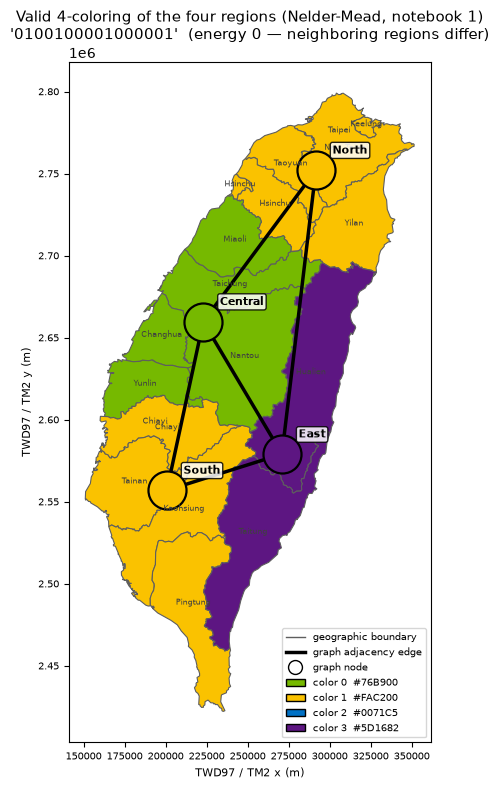

SUMMARY
------------------------------------------------------------------
optimizer          : Nelder-Mead vs notebook 0's COBYLA, same 50-evaluation budget
best energy        : this notebook 10.472883 | notebook 0 (COBYLA, GPU) 17.305686
valid-sample rate  : 1.9250% of 20,000 shots (this notebook)
------------------------------------------------------------------
Nelder-Mead lands far below notebook 0's COBYLA energy on the same evaluation budget, and the resulting valid-sample rate is far above notebook 0's.


In [5]:
# cell 5 — draw the decoded coloring, then compare against notebook 0.
best_coloring = result["assignment"]
unit_colors = {}
for name, county in taiwan["counties"].items():
    unit_colors[name] = hp.PALETTE[best_coloring[county["region"]]]
node_colors = {}
for region in hp.REGION_ORDER:
    node_colors[region] = hp.PALETTE[best_coloring[region]]

fig, ax = hp.plot_map(taiwan, unit_colors=unit_colors,
                      node_pos=hp.group_positions(taiwan, "region"), edges=EDGES,
                      node_colors=node_colors, unit_labels=True, color_legend=True,
                      title="Valid 4-coloring of the four regions (Nelder-Mead, notebook 1)\n"
                            f"'{result['best']}'  (energy 0 — neighboring regions differ)")
plt.show()

print("SUMMARY")
print("-" * 66)
print(f"optimizer          : Nelder-Mead vs notebook 0's COBYLA, same 50-evaluation budget")
print(f"best energy        : this notebook {best_energy:.6f} | notebook 0 (COBYLA, GPU) "
      f"{cobyla_best_energy_notebook0:.6f}")
print(f"valid-sample rate  : {result['valid_rate']:.4%} of 20,000 shots (this notebook)")
print("-" * 66)
print("Nelder-Mead lands far below notebook 0's COBYLA energy on the same evaluation budget, "
      "and the resulting valid-sample rate is far above notebook 0's.")